# PMR3404 - Controle I
# Experiência 4: Técnicas no domínio da frequência

# Identificação

**Aluno :Matheus Alexandrino Brito**           **NUSP:11261419**

**Aluno :Augusto Campos**           **NUSP:13684662**

**Aluno :Arthur Magalhães Marcolino**           **NUSP:13684582**

**Turma de Laboratório: 2B**

**Professor: Newton**

**Versão 2026**


## Instruções para submissão do relatório

1. Todo relatório deve ser submetido no sistema Moodle de acordo com o deadline estabelecido.
2. Submeta um arquivo compactado contendo o arquivo principal do jupyter notebook (.ipynb) e o folder ./Figuras mesmo que não tenha colocado imagens adicionais.
3. Também no arquivo compactado acrescente uma versão no formato HTML do arquivo jupyter notebook. No menu acesse "File->Save and Export Notebook as ...". O arquivo será utilizado para avaliação do relatório, caso haja dúvidas sobre os resultados o arquivo .ipynb será verificado.
4. **Nos arquivos .ipynb e .html você deve manter as células que contêm as saídas das execuções dos scripts em Python com as últimas respostas obtidas. Seções que não apresentarem indícios que os scripts foram executados não serão consideradas para nota.**

# 1. Regime permanente senoidal

Dado um sistema representado por $H(s)$, sabemos que o regime permanente senoidal pode ser calculado fazendo $s=j\omega$, ou seja, $H(j\omega)$.

Para uma eventual entrada $u(t)=X\sin(\omega t)$ a saída $y(t)$ pode ser calculada da seguinte forma:
$$
y(t)= Y\sin(\omega t + \Phi)
$$
onde $Y=|H(j\omega)|X$ e $\Phi=\angle H(j\omega)$

Seja o seguinte Filtro Ativo de 1a. ordem ilustrado na figura a seguir.

<img src="./Figuras/FiltroAtivo.png" width="70%" height="70%"/>

Seria perfeitamente possível realizar o levantamento experimental da resposta em frequência injetando um sinal senoidal na entrada do circuito e verificar o módulo e a fase do sinal senoidal na saída do circuito. 
Realizando esse procedimento para várias frequências angulares $\omega$ é possível traçar os gráficos aproximados de módulo e fase.

Sabemos no entanto que a função de transferência equivalente do circuito é dada por:
$$
H(j\omega)= \frac{A_{CL}}{j\omega T+1},
$$
onde o ganho é dado por $A_{CL}=R_2/R_1$ e a constante de tempo $T=R_2C$.

a-) Calcule as expressões analíticas de módulo e fase em função da frequência angular $\omega$:
$$
|H(j\omega| = \frac{|A_{CL}|}{\sqrt{1 + (\omega T)^2}}
$$
$$
\angle H(j\omega) =  -\arctan(\omega T)
$$

b-) Considerando os seguintes valores para os componentes:
- $R_1=330\Omega$
- $R_2=3.3K\Omega$
- $C=10nF$

Calcule as expressões de módulo e fase em função da frequência angular $\omega$ agora com valores numéricos:
$$
|G(j\omega| = \frac{3{,}3\text{ k}\Omega / 330\Omega}{\sqrt{1 + (\omega \cdot 3{,}3\text{ k}\Omega \cdot 10\text{ nF})^2}}
= \frac{10}{\sqrt{1 + (0.000033 \cdot \omega)^2}}$$
$$
\angle G(j\omega) = -\arctan(0.000033\omega )
$$

c-) Podemos agora calcular o diagrama de Bode através dessas expressões e utilizando um gráfico semi-logaritmico.
    Utilizando o script abaixo insira as expressões desenvolvidas para o módulo e fase nas linhas adequadas.
    
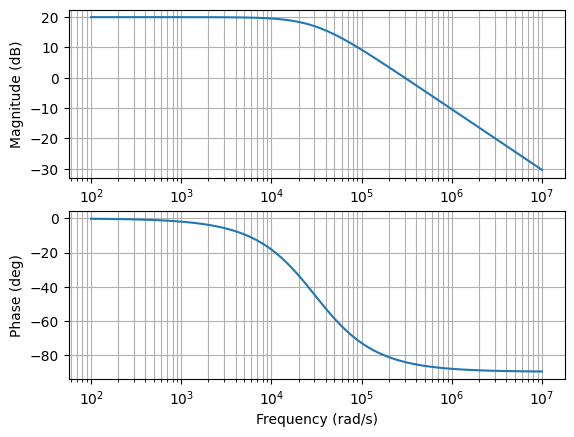


Text(0, 0.5, 'Phase (deg)')

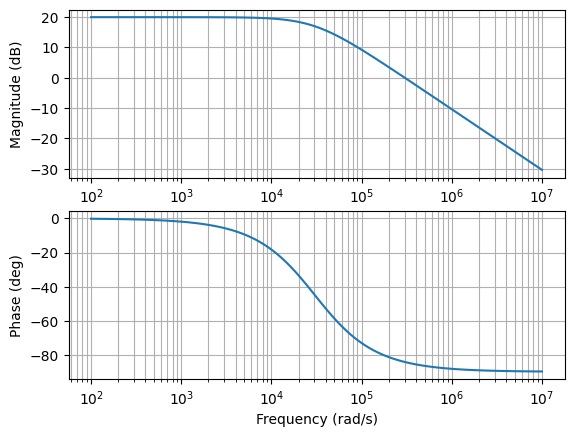

In [24]:
%matplotlib inline
import numpy as np
import control.matlab as co
import matplotlib.pyplot as plt
# Parametros do circuito
R1= 330
R2= 3.3*10**3
C= 10*10**(-9)
K = R2/R1           # ganho
T = R2*C            # cte de tempo
# Geracao da escala da frequencia angular rad/s
omega = np.logspace(2,7,num=100,base=10)
# insira aqui sua formula para o modulo
mag = K / np.sqrt(1 + (omega*T)**2)
# Conversao para dB
magdB = 20*np.log10(mag)
# insira aqui a sua formula para a fase
phase = -np.arctan(omega*T)
# Conversao de rad para grau
phase_deg = phase*180.0/np.pi
# Geracao de vetor de freq angular rad/s
f, (ax1,ax2) = plt.subplots(2,1)
ax1.semilogx(omega,magdB)
ax1.grid(which="both")
ax1.set_xlabel('Frequency (rad/s)')
ax1.set_ylabel('Magnitude (dB)')
ax2.semilogx(omega,phase_deg)
ax2.grid(which="both")
ax2.set_xlabel('Frequency (rad/s)')
ax2.set_ylabel('Phase (deg)')

# 2. Geração de diagramas de Bode

Seja um sistema dinâmico descrito pela seguinte função de transferência:
$$
G(s) = \frac{(s+3)}{[(s+2)(s^2+2s+25)]}
$$

O esboço manual do diagrama de Bode $G(s)$ é usualmente realizado separando a função de transferência em fatores básicos:
1. Ganho: $K$
2. Fator integral: $1/s$
3. Fator derivativo: $s$
4. Fator de 1a. ordem - pólo: $1/(1+sT)$
5. Fator de 1a. ordem - zero: $(1+sT)$
6. Fator de segunda ordem - pólos:
$$
\frac{1}{\left[ 1+2\zeta\left(\frac{s}{\omega_n}\right) + \left( \frac{s}{\omega_n} \right)^2 \right]}
$$
7. Fator de segunda ordem - zeros:
$$
\left[ 1+2\zeta\left(\frac{s}{\omega_n}\right) + \left( \frac{s}{\omega_n} \right)^2 \right]
$$

a-) Para a função de transferência $G(s)$ dada acima calcule os fatores básicos segundo os ítens 1-7 descritos acima:

- Ganho:
$$G_1(s)= 3/50$$

- Zero:
$$G_2(s)= (1+\frac{s}{3})$$

- Pólo:
$$G_3(s)= \frac{1}{1 + \frac{s}{2}}$$

- 2a. ordem:
$$G_4(s)= \frac{1}{1 + \frac{2s}{25} + \frac{s^2}{25}}$$

b-) Calcule o diagrama de Bode dos fatores $G_1$, $G_2$, $G_3$, $G_4$. Utilize o script abaixo.

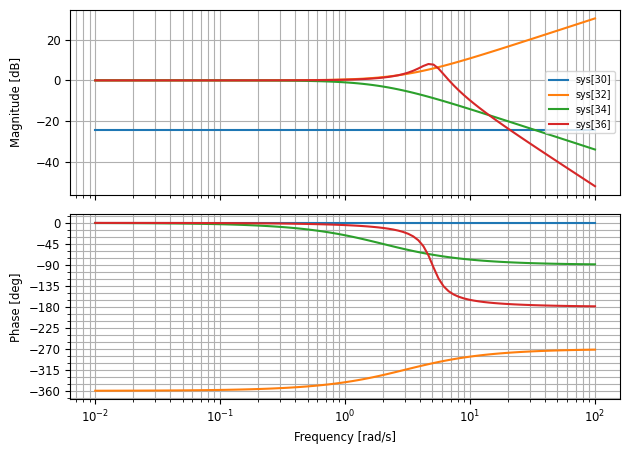

c-) Sabemos que os gráfico do módulo em dB e os gráficos da fase podem ser somados. **Essa seria estratégia
para o esboço manual**. Utilizando o 2o. script abaixo. Verifique se o resultado está correto utilizando o 3o. script abaixo.

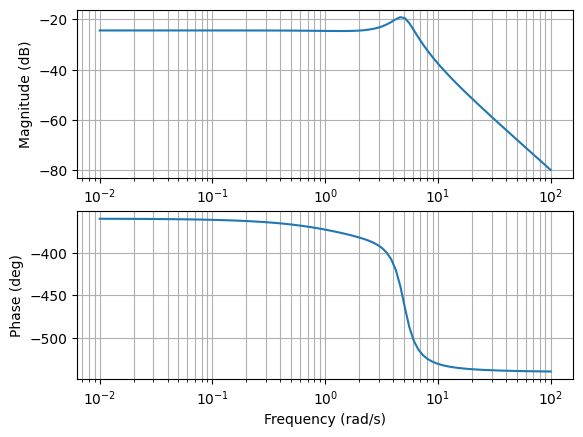


C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(
C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(
C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(
C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplo

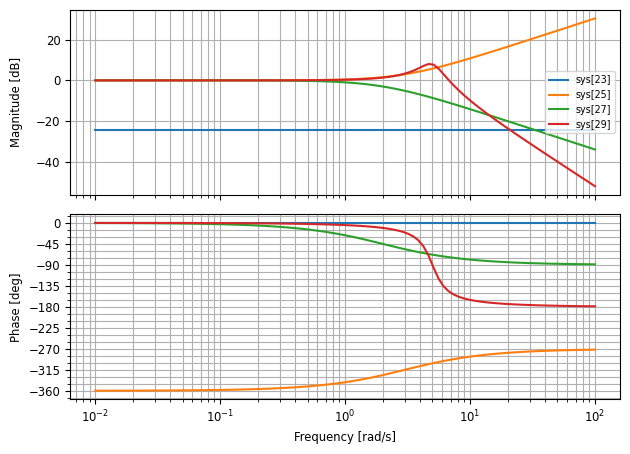

In [29]:
%matplotlib inline
import numpy as np
import control.matlab as co
import matplotlib.pyplot as plt
plt.figure(1)
omega = np.logspace(-2,2,num=100,base=10)
s=co.tf('s')
G0 = co.tf([3],[50])
# Obs: mag0, mag1, etc. nao estao em dB, embora o grafico esteja
# Todas os diagramas de Bode a seguir sao colocados na mesma figura
[mag0,phi0,w]=co.bode(G0,omega,dB=True,Hz=False,deg=True)
G1 = co.tf([1/3, 1],[1])
[mag1,phi1,w]=co.bode(G1,omega,dB=True,Hz=False,deg=True)
G2 = co.tf([1], [1/2, 1])
[mag2,phi2,w]=co.bode(G2,omega,dB=True,Hz=False,deg=True)
G3 = co.tf([1], [1/25, 2/25, 1])
[mag3,phi3,w]=co.bode(G3,omega,dB=True,Hz=False,deg=True)

Text(0, 0.5, 'Phase (deg)')

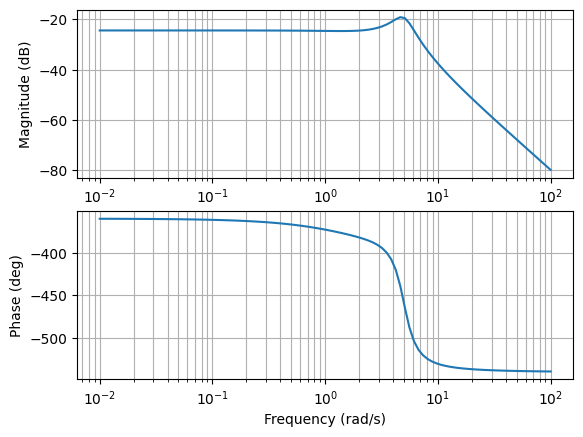

In [26]:
# Continuacao do script acima
# Diagrama de Bode utilizando o conceito de soma
# dos fatores basicos
# Conversao para dB
%matplotlib inline
mag0dB = 20*np.log10(mag0)
mag1dB = 20*np.log10(mag1)
mag2dB = 20*np.log10(mag2)
mag3dB = 20*np.log10(mag3)
# Somatorio dos modulos em dB
magt = mag0dB+mag1dB+mag2dB+mag3dB
# Somatoria das fases e conversao para grau
phit = 180*(phi0+phi1+phi2+phi3)/np.pi
f, (ax1,ax2) = plt.subplots(2,1)
ax1.semilogx(omega,magt)
ax1.grid(which="both")
ax1.set_xlabel('Frequency (rad/s)')
ax1.set_ylabel('Magnitude (dB)')
ax2.semilogx(omega,phit)
ax2.grid(which="both")
ax2.set_xlabel('Frequency (rad/s)')
ax2.set_ylabel('Phase (deg)')

C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


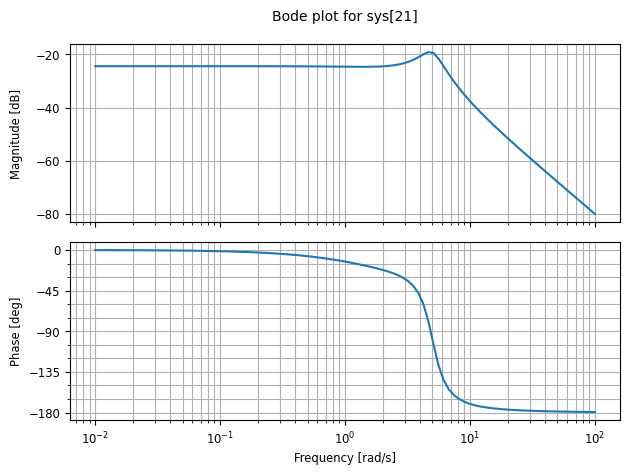

In [27]:
%matplotlib inline
# Verificacao do Diagrama de Bode de G(s)
# Verifica se o resultado acima e' coerente
s=co.tf('s')
G=(s+3)/((s+2)*(s**2+2*s+25))
[modulo,fase,w]=co.bode(G,omega,dB=True,Hz=False,deg=True)

## Uma digressão

A figura abaixo contêm um resumo das margens de estabilidade no diagrama de Bode e
no gráfico polar de Nyquist.

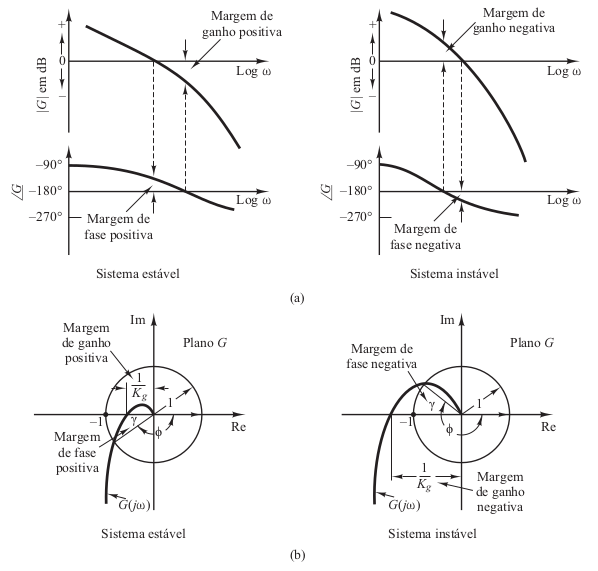



## 3. Margens de estabilidade no diagrama de Bode

Na Experiência 1 foi definido o sistema de controle de posição da antena parabólica.

<img src="./Figuras/diagblocoPosicaoDashed.png" width="70%" height="70%"/>

A planta pode ser escrita como:
$$
\frac{\Theta_o(s)}{V_p(s)}=G_\theta(s)=\frac{K_1 K_m K_g}{s(s+a)(s+a_m)}
$$

Os parâmetros do sistema estão definidos na Tabela abaixo:

| Parâmetro | Valor |
|:--|:--|
|$K_{pot}$ | 0.318 |
|$K_{tac}$ | 0.48 |
|$K_1$     | 100 |
|$a$       | 100 |
|$K_m$     | 2.083 |
|$a_m$     | 1.71 |
|$K_g$     | 0.1 |
        
Para o sistema de de controle de posição o controlador é escrito através da seguinte forma geral:
$$
H_\theta(s)=K_{pot}H_1(s).
$$

No ítem 6 da Experiência 2 foi utilizado um controlador PD com filtro:
$$
H_1(s) = K_p \left( 1 + T_d\frac{s}{\frac{T_d}{N}s+1} \right)
$$

Foi proposto o projeto de um sistema de controle que atendesse as seguintes especificações:
- Erro estático nulo para uma entrada degrau unitário $\theta_{e_{ss}}=0$,
- Tempo de subida $t_r < 1.0s$,
- Tempo de assentamento $t_s < 5s$,
- Máximo sobresinal $M_p < 10\%$.

Utilizando $N=100$ e $T_d=0.5$ foi proposto o projeto de um ganho proporcional do controlador
$K_p$ utilizando lugar das raízes.

Esse sistema se torna instável somente para uma faixa de valores muito elevada da constante proporcional $K_p$ como será verificado abaixo.
As margens de estabilidade são muito elevadas no entanto sabemos que a faixa valores de $K_p$ que atendem às especificações de controle e que também são fisicamente plausíveis é bem mais reduzida quando comparada a faixa de valores que garantem estabilidade.

Aqui vamos utilizar a ferramenta sisotool do pacote de sistemas de controle da linguagem Python para analisar as margens de estabilidade do sistema (Obs: Essa ferramenta é similar ao do Matlab).
Para cada valor de $K_p$ solicitado no ítem b-) você deve posicionar os pólos na ferramenta sisotool e verificar as margens de estabilidade para aquele ponto.
**Não é necessário ser muito preciso em relação ao valor de $K_p$ já que a ferramenta sisotool é em geral muito lenta. Para o valor de $K_p$ que conseguir altere o valor na tabela abaixo**

a-) Utilizando o método de Routh-Hurwitz estime o intervalo dos valores do ganho proporcional $K_p$ tal que o sistema seja estável.

**[Coloque os valores numéricos dos limites]**

$$
0 < K_p < 8932
$$

b-) Indique o valor do ganho proporcional para um sistema marginalmente estável:

$$
K_p^{marg} = 8932
$$

b-) Utilizando a ferramenta sisotool vamos analisar como as margens de estabilidade variam com o valor do
    ganho proporcional $K_p$.
    
-$K_p=70$:

**[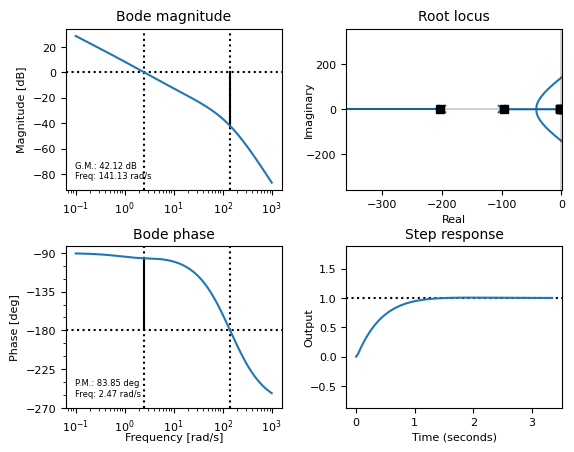]**

-$K_p=500$:

**[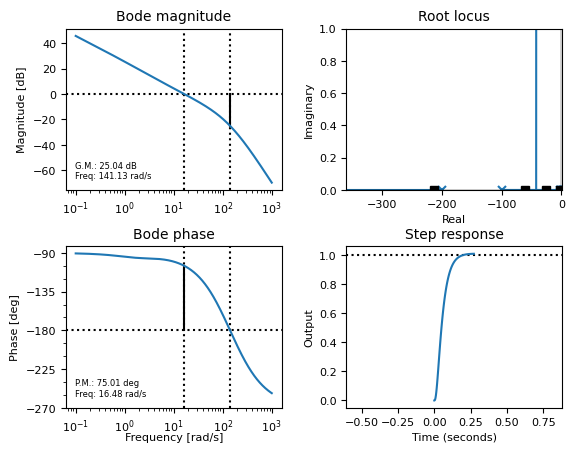]**

-$K_p=2000$:

**[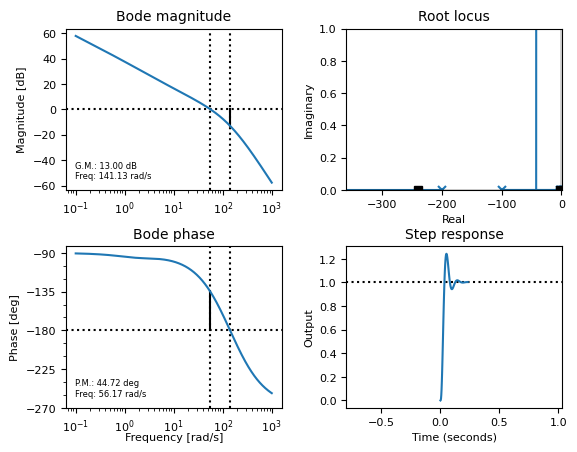]**

-$K_p=8900$:

**[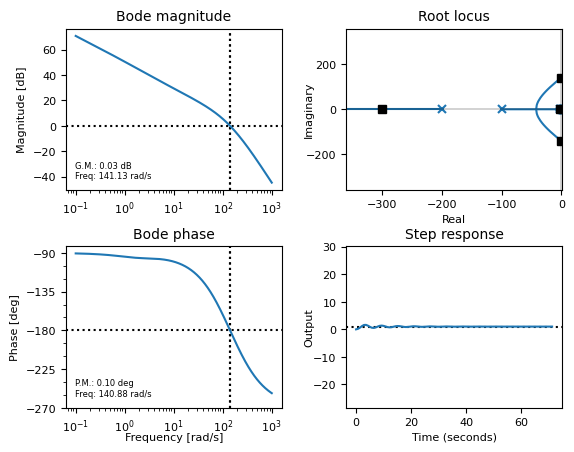]**

-$K_p=8950$:

**[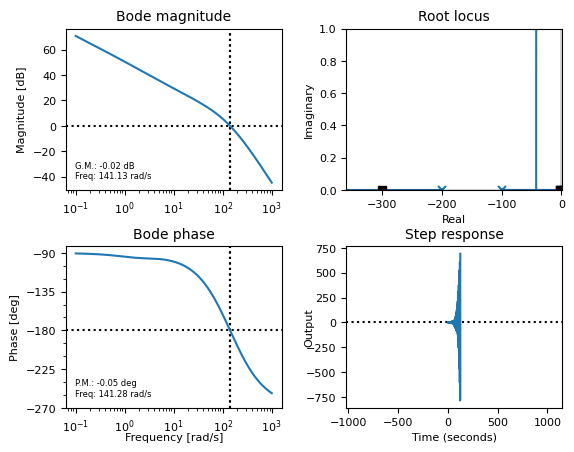]**

- Preencha a tabela abaixo:

|$K_p$|$G_m$|$\omega_g$ |$PM$|$\omega_p$|
|:-|:-|:-|:-|:-|
|70|   42,12 | 141,13 | 83,85 |   2,47 |
|500|  25,04 | 141,13 | 75,01 |  16,48 |
|2000| 13,00 | 141,13 | 44,72 |  56,17 |
|8900|  0,03 | 141,13 |   0,1 | 140,88 |
|8950| -0,02 | 141,13 | -0,05 | 141,28 |


c-) Qual o efeito do aumento do ganho proporcional $K_p$ sobre o gráfico do ganho $|GH_p(j\omega)|$ ?

**Com o aumento de 𝐾𝑝, o valor de 𝐺𝑚 se aproxima de zero até 𝐾𝑝=8932; a partir daí, 𝐺𝑚 passa a decrescer. Já 𝜔𝑔 permanece constante.**

d-) Qual o efeito do aumento do ganho proporcional $K_p$ sobre o gráfico da fase $\angle GH_p(j\omega)$ ?

**Com o aumento de 𝐾𝑝, o valor de 𝑃𝑀 se aproxima de zero até 𝐾𝑝=8932; a partir desse ponto, passa a decrescer. Já 𝜔𝑝 cresce de forma diretamente proporcional a 𝐾𝑝.**


-------------
FT da planta Gp(s) = 
<TransferFunction>: sys[362]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

           20.83
  -----------------------
  s^3 + 101.7 s^2 + 171 s
-------------
FT DE MALHA ABERTA GHp(s)=Gp(s)*Hp(s) = 
<TransferFunction>: sys[378]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

              2.994e+06 s + 5.928e+06
  ------------------------------------------------
  0.5 s^4 + 150.9 s^3 + 1.026e+04 s^2 + 1.71e+04 s
-------------
POLOS E ZEROS DE MALHA ABERTA
Polos de GHp(s) =  [-200.  +0.j -100.  +0.j   -1.71+0.j    0.  +0.j]
Zeros de GHp(s) =  [-1.98019802+0.j]


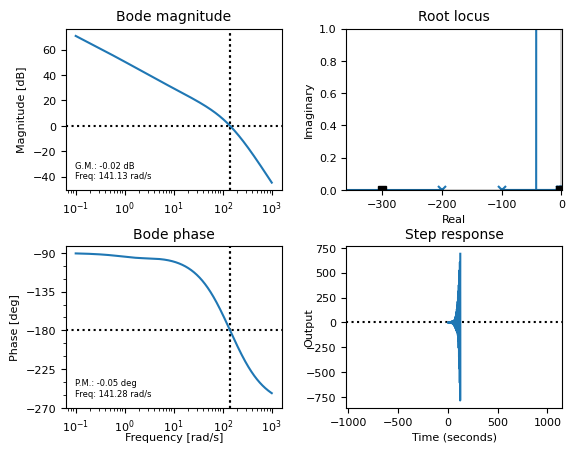

In [43]:
# qt - abre uma janela fora do Browser
%matplotlib inline
# Python packages
import numpy as np
import control.matlab as co
import matplotlib.pyplot as plt
#
# Controle da posicao angular do motor eletrico CC
# Controle de Posicao Angular com controlador PID
#
# Definicao dos valores dos parametros do sistema
# Constante do potenciometro
Kpot = 0.318;
# Parametros da funcao de transferencia Gp(s)
K1 = 100;
Km = 2.083;
Kg = 0.1;
a  = 100;
am = 1.71;
# Funcao de transferencia da posicao angular do sistema Gp(s)
# Definicao de s como funcao de transferencia
s = co.tf('s');
Gp = (K1*Km*Kg)/(s*(s+a)*(s+am))
print('-------------')
print('FT da planta Gp(s) = ')
print(Gp)
# Inicialmente Kp=1 para LR
Kp = 8950
Td = 0.5
N  = 100
# Controlador PD com filtro
H1 = Kp*(1+Td*s/(Td*s/N+1))
# Controlador Hp(s)
Hp = Kpot*H1
# Malha aberta
GHp=Gp*Hp
print('-------------')
print('FT DE MALHA ABERTA GHp(s)=Gp(s)*Hp(s) = ')
print(GHp)
print('-------------')
print('POLOS E ZEROS DE MALHA ABERTA')
print('Polos de GHp(s) = ', co.pole(GHp))
print('Zeros de GHp(s) = ', co.zero(GHp))
co.sisotool(GHp)

## 4. Resposta transitória versus banda passante $\omega_b$
                                                                             
O comportamento desejado de um sistema de controle em malha fechada no domínio da frequência é equivalente ao de um **filtro
passa baixa**.
 
A banda passante $\omega_b$ é definida como o intervalo entre a frequência 0 e a frequência de corte.
A frequência de corte é a frequência aonde o ganho é -3dB inferior ao ganho constante em baixa frequência.
No caso do filtro passa baixa o valor da frequência de corte e da banda passante coincidem.

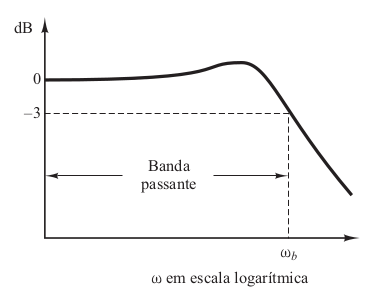

O valor da banda passante influencia a resposta transitória do sistema de controle. Sinais de entrada $u(t)$ com frequência
acima da frequência de corte são filtrados.

Vamos ilustrar essa característica através de um exemplo. Seja um sistema de controle em malha fechada onde:
$$
G(s) = \frac{1}{s(s+a)},
$$
e                                                                                                                                  
$$
H(s)=K=1.
$$

a-) Utilize o script abaixo para gerar as respostas a degrau do sistema de controle em malha fechada para $a=\{0.5,1.0,2.0,4.0\}$

**[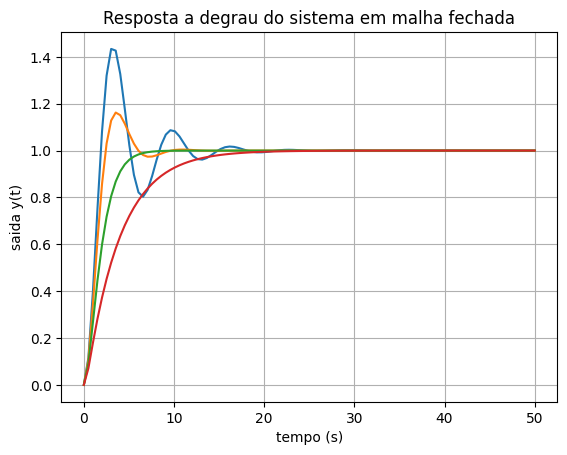]**

b-) Utilize o script abaixo para gerar os diagramas de Bode do sistema de controle em malha fechada  para $a=\{0.5,1.0,2.0,4.0\}$

**[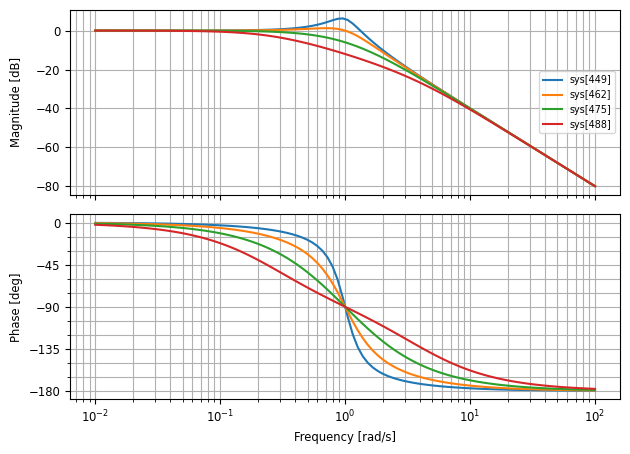]**

c-) Preencha a tabela abaixo:

|a|$\zeta$|$\omega_n$|$t_r$|$M_p$|$B_w$|
|:-:|:-:|:-:|:-:|:-:|:-:|
|0.5|0,25|1,49|1,26|44,43|1,49|
|1.0|0,50|1,27|1,67|16,30|1,27|
|2.0|1,00|1,00|3,35|00,00|0,64|
|4.0|1,00|3,732|8,33|00,00|0,27|

d-) Baseado nos resultados apresentados na tabela acima qual a relação entre as características da resposta transitória ($M_p$ e $t_r$) e a banda passante $B_w$ ?

**Os valores de 𝑀𝑝 e 𝑡𝑟 são inversamente proporcionais: conforme 𝑡𝑟 cresce, 𝑀𝑝 diminui até se anular em um limite, depois disso Mp vira 0. Já a relação entre 𝑡𝑟 e 
𝐵𝑤 também é inversa, mas neste caso 𝐵𝑤 apenas reduz, sem tender a zero.**

----------------
caso a =  0.5
-------------
Polos e zeros cloop
Polos =  [-0.25+0.96824584j -0.25-0.96824584j]
Zeros =  []
COEF. DE AMORTECIMENTO E FREQ. NATURAL
_____Polos____________zeta_______omegan
    Eigenvalue (pole)       Damping     Frequency
     -0.25   +0.9682j          0.25             1
     -0.25   -0.9682j          0.25             1
-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop
tempo de subida tr =  1.26 seg
tempo de acomodacao ts =  14.32 seg
maximo sobresinal Mp =  44.424787527153306
valor de pico thetaomax =  1.44
instante de pico tp =  3.27 seg
valor de regime estacionario yss =  1.00


C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


----------------
caso a =  1.0
-------------
Polos e zeros cloop
Polos =  [-0.5+0.8660254j -0.5-0.8660254j]
Zeros =  []
COEF. DE AMORTECIMENTO E FREQ. NATURAL
_____Polos____________zeta_______omegan
    Eigenvalue (pole)       Damping     Frequency
      -0.5    +0.866j           0.5             1
      -0.5    -0.866j           0.5             1
-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop
tempo de subida tr =  1.67 seg
tempo de acomodacao ts =  8.09 seg
maximo sobresinal Mp =  16.303349290419632
valor de pico thetaomax =  1.16
instante de pico tp =  3.63 seg
valor de regime estacionario yss =  1.00
----------------
caso a =  2.0
-------------
Polos e zeros cloop
Polos =  [-1.+0.j -1.+0.j]
Zeros =  []
COEF. DE AMORTECIMENTO E FREQ. NATURAL
_____Polos____________zeta_______omegan
    Eigenvalue (pole)       Damping     Frequency
                   -1             1             1
                   -1             1             1
-------------
CARACTERISTICAS DA 

C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(
C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


----------------
caso a =  4.0
-------------
Polos e zeros cloop
Polos =  [-3.73205081+0.j -0.26794919+0.j]
Zeros =  []
COEF. DE AMORTECIMENTO E FREQ. NATURAL
_____Polos____________zeta_______omegan
    Eigenvalue (pole)       Damping     Frequency
               -3.732             1         3.732
              -0.2679             1        0.2679
-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop
tempo de subida tr =  8.33 seg
tempo de acomodacao ts =  15.10 seg
maximo sobresinal Mp =  0.0
valor de pico thetaomax =  1.00
instante de pico tp =  25.78 seg
valor de regime estacionario yss =  1.00


C:\Users\nigtt\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


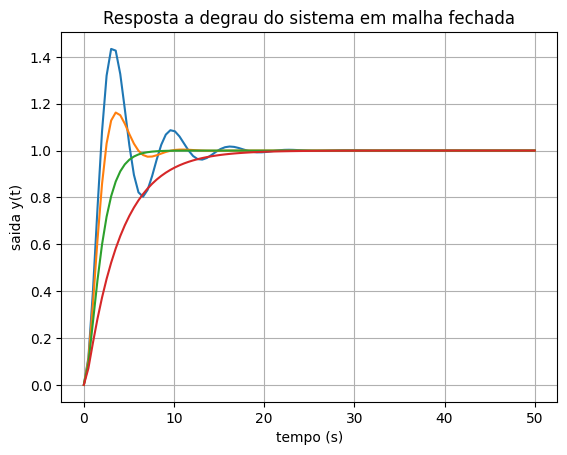

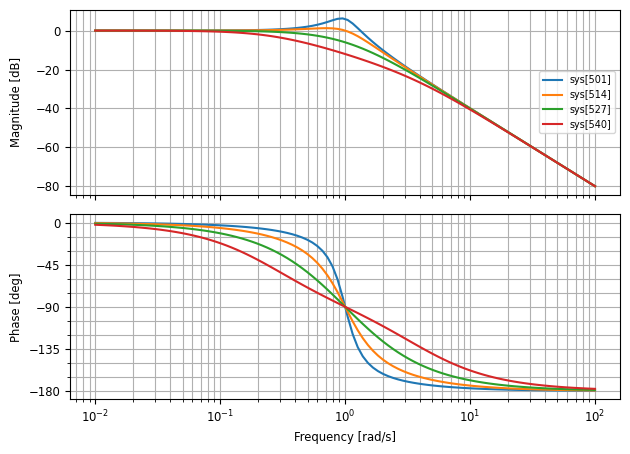

In [46]:
# qt - abre uma janela fora do Browser
# Para estimativa da frequencia angular de corte melhor usar qt
#%matplotlib qt
# modo inline
%matplotlib inline
# Python packages
import numpy as np
import control.matlab as co
import matplotlib.pyplot as plt
# Definição do sistema de 2a. ordem
s=co.tf('s')
K = 1
H = K
# definicao da escala do tempo e frequencia para os graficos
t = np.linspace(0,50,100)
omega = np.logspace(-2,2,num=100,base=10)
# a e' um dos polos do sistema de 2a. ordem
for a in [0.5,1.0,2.0,4.0]:
   print('----------------')
   print('caso a = ',a)
   G=1/(s*(s+a))
   GH = G*H
   cloop = co.feedback(GH,1)
   print('-------------')
   print('Polos e zeros cloop')
   print('Polos = ',co.pole(cloop))
   print('Zeros = ',co.zero(cloop))
   print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
   print('_____Polos____________zeta_______omegan')
   co.damp(cloop)
   # Calculo das caracteristicas da resposta transitória
   S1 = co.stepinfo(cloop)
   print('-------------')
   print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA cloop')
   print('tempo de subida tr = ','%.2f' % S1['RiseTime'],'seg')
   print('tempo de acomodacao ts = ','%.2f' % S1['SettlingTime'],'seg')
   print('maximo sobresinal Mp = ',S1['Overshoot'])
   print('valor de pico thetaomax = ','%.2f' % S1['Peak'])
   print('instante de pico tp = ','%.2f' % S1['PeakTime'],'seg')
   print('valor de regime estacionario yss = ','%.2f' % S1['SteadyStateValue'])
   # plota a resposta a degrau
   # todos na mesma figura
   plt.figure(1)
   y,t = co.step(cloop,t)
   plt.plot(t,y)
   plt.title('Resposta a degrau do sistema em malha fechada')
   plt.xlabel('tempo (s)')
   plt.ylabel('saida y(t)')
   plt.grid(True)
   plt.show
   #
   # Plota os diagramas de Bode do sistema de controle
   # em malha fechada
   # todos os plots na mesma figura
   # A estimativa de wc pode ser feita utilizando a opcao qt
   plt.figure(2)
   [mag,phi,w]=co.bode(cloop,omega,dB=True,Hz=False,deg=True)
   plt.show

## 5. Discussões

Na primeira seção, a ideia foi entender como o filtro ativo de primeira ordem se comporta quando excitado por um sinal senoidal em regime permanente. Ficou claro como ganho e fase mudam conforme a frequência varia — a atenuação vai crescendo acima da frequência de corte, e a defasagem acompanha esse movimento por conta do termo −arctan(ωT). Essa análise serve de base para o diagrama de Bode e mostra por que a constante de tempo T é tão central para a resposta do circuito.

Na segunda, o foco foi construir os diagramas de módulo e fase — tanto a partir das expressões analíticas quanto com o script computacional. Colocar os dois lado a lado foi útil: dá para ver que o modelo matemático realmente bate com as curvas geradas, e também fica mais visual a transição entre o que acontece em baixas e altas frequências. Trabalhar em dB e graus ajuda bastante aqui — torna mais intuitivo analisar como o sistema filtra sinais e pensar em termos de estabilidade.

Na terceira, a análise foi além e entrou nas margens de ganho e fase. Essas margens dizem o quanto o sistema ainda aguenta antes de chegar perto de instabilidade — seja por realimentação ou variações de ganho. Saber avaliá-las permite ter uma noção real de robustez do projeto e de quanto ele tolera variações nas condições de operação sem perder o comportamento esperado.

A quarta seção fechou conectando a resposta transitória com a largura de banda. Uma banda passante maior tende a acelerar a resposta, mas normalmente traz mais overshoot; uma banda mais estreita deixa tudo mais lento e amortecido. Quando estamos projetando é necessário entender o que é mais importante entre velocidade de resposta e estabilidade.

## 6. Conclusões

As quatro seções constroem uma linha de raciocínio contínua: entender como ganho e fase se comportam em frequência abre caminho para o diagrama de Bode, que por sua vez revela as margens de estabilidade, que finalmente se conectam com o que acontece no domínio do tempo. O que fica claro no fim é que frequência de corte, largura de banda, overshoot e margens não são conceitos separados — são faces diferentes do mesmo sistema. Saber ler um diagrama de Bode, nesse sentido, é menos sobre traçar curvas e mais sobre enxergar como o circuito vai se comportar antes mesmo de testá-lo.